In [1]:
## Bayesian hierarchical prediction intervals
# Diagnostics for the hierarchical hour-of-day sigma model in energy_forecast.bayesian_interval,
# used by forecast.bayesian_hierarchical_forecast. Point forecast is unchanged (same OLS lag +
# period-dummy regression as forecast_with_interval) -- only the interval is modelled here.
#
# 1. Prior predictive check
# 2. Fit on real training residuals + convergence diagnostics (centered parameterisation, default)
# 3. Centered (default) vs non-centered parameterisation comparison
# 4. tau prior sensitivity check
# 5. Posterior predictive coverage vs the current pooled +/-1.96*std baseline
# 6. Shrinkage plot: unpooled per-hour std vs pooled hierarchical estimate

In [2]:
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

from energy_forecast.data import load_demand_data
from energy_forecast.features import build_features
from energy_forecast.forecast import _fit_mean_model, forecast_with_interval
from energy_forecast.config import HierarchicalSigmaPriors
from energy_forecast.bayesian_interval import (
    build_hierarchical_sigma_model,
    fit_hierarchical_sigma_model,
    predict_interval,
)

g++ not available, if using conda: `conda install gxx`


In [3]:
raw = load_demand_data("../data/demanddata_2024.csv")
df = build_features(raw)

# Same 80/20 chronological split used during the earlier residual diagnostics.
n = len(df)
split_idx = int(n * 0.8)
split_date = df.index[split_idx]

train_df, test_df, y_pred_train, y_fore = _fit_mean_model(df, split_date)
y_resid = train_df["ND"] - y_pred_train
train_hour = train_df["hour"]
test_hour = test_df["hour"]

print("split_date:", split_date)
print(f"train rows: {len(train_df)}, test rows: {len(test_df)}")
print(f"train residual mean: {y_resid.mean():.4f}, std: {y_resid.std():.2f}")

split_date: 2024-10-21 04:30:00+00:00
train rows: 13785, test rows: 3447
train residual mean: 0.0000, std: 414.07


Sampling: [alpha, gamma, resid_obs, tau]


count    24000.000000
mean       545.605195
std        532.933745
min         12.151703
5%         141.537352
25%        280.119844
50%        431.448712
75%        650.568656
95%       1274.739569
max      19765.195870
dtype: float64


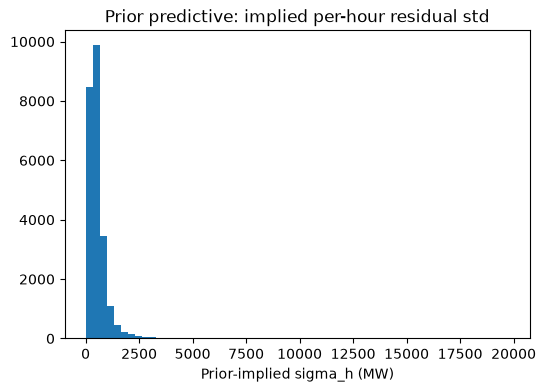

In [4]:
## 1. Prior predictive check
# Simulate sigma_h from the priors alone (no data), before fitting anything, to sanity-check
# the implied magnitude of the per-hour residual std is plausible (order of tens to low
# thousands of MW -- not single digits, not six figures).

priors = HierarchicalSigmaPriors()
model = build_hierarchical_sigma_model(y_resid, train_hour, priors)

with model:
    prior_pred = pm.sample_prior_predictive(draws=1000, random_seed=0)

sigma_h_prior = prior_pred.prior["sigma_h"].to_numpy().reshape(-1)
print(pd.Series(sigma_h_prior).describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(sigma_h_prior, bins=60)
ax.set_xlabel("Prior-implied sigma_h (MW)")
ax.set_title("Prior predictive: implied per-hour residual std")
plt.show()

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, tau, gamma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


        mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
alpha   5.86   0.09      5.7        6      144      128  1.04    0.0078  0.0061
tau    0.435  0.068     0.34     0.56     1150     1513  1.00     0.002  0.0019
divergences (centered, default): 0


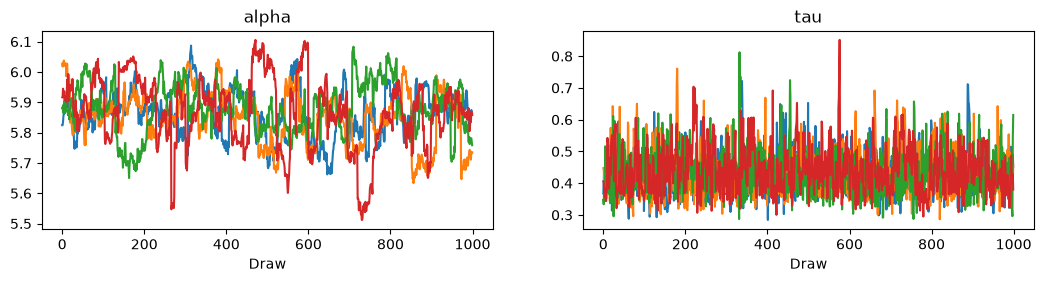

In [5]:
## 2. Fit on real training residuals + convergence diagnostics

trace = fit_hierarchical_sigma_model(model, priors, random_seed=0)

print(az.summary(trace, var_names=["alpha", "tau"]))

n_divergences_centered = int(trace.sample_stats["diverging"].sum())
print(f"divergences (centered, default): {n_divergences_centered}")

az.plot_trace(trace, var_names=["alpha", "tau"])

In [6]:
## 3. Centered (default) vs non-centered parameterisation
# Same model, gamma_raw ~ Normal(0, 1) with gamma = gamma_raw * tau instead of gamma ~ Normal(0, tau)
# directly. Non-centered is the usual funnel-avoidance default, but with ~574 obs/hour bucket the
# groups are fairly well-identified by their own data, which is the regime where centered sampling
# can be comparable or better -- this is exactly what showed up here (see section 2's ESS for tau
# vs this cell's), which is why centered shipped as the module default.

def build_noncentered_sigma_model(train_resid, train_hour, priors):
    coords = {"hour": np.arange(priors.n_hour_buckets)}
    with pm.Model(coords=coords) as noncentered_model:
        hour_idx = pm.Data("hour_idx", train_hour.to_numpy(), dims="obs_id")
        resid_data = pm.Data("resid_data", train_resid.to_numpy(), dims="obs_id")

        alpha = pm.Normal("alpha", priors.alpha_mu, priors.alpha_sigma)
        tau = pm.HalfNormal("tau", priors.tau_sigma)
        gamma_raw = pm.Normal("gamma_raw", 0.0, 1.0, dims="hour")  # non-centered
        sigma_h = pm.Deterministic("sigma_h", pm.math.exp(alpha + gamma_raw * tau), dims="hour")

        sigma_obs = sigma_h[hour_idx]
        pm.Normal("resid_obs", mu=0.0, sigma=sigma_obs, observed=resid_data, dims="obs_id")
    return noncentered_model


noncentered_model = build_noncentered_sigma_model(y_resid, train_hour, priors)
noncentered_trace = fit_hierarchical_sigma_model(noncentered_model, priors, random_seed=0)

n_divergences_noncentered = int(noncentered_trace.sample_stats["diverging"].sum())
print(f"divergences -- centered (default): {n_divergences_centered}, non-centered: {n_divergences_noncentered}")
print()
print("alpha/tau summary, non-centered parameterisation:")
print(az.summary(noncentered_trace, var_names=["alpha", "tau"]))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, tau, gamma_raw]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 13 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


divergences -- centered (default): 0, non-centered: 0

alpha/tau summary, non-centered parameterisation:
       mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
alpha  5.88  0.083      5.7        6      184      262  1.04    0.0061  0.0045
tau    0.43  0.067     0.34     0.55      182      271  1.02    0.0051  0.0043


In [7]:
## 4. tau prior sensitivity check
# tau's posterior is identified by the *number* of groups (24) more than observations per
# group, so -- unlike alpha -- its prior can stay influential even with plenty of data per
# group. Refit with a wider HalfNormal(1.0) and compare.

priors_wide_tau = replace(priors, tau_sigma=1.0)
model_wide_tau = build_hierarchical_sigma_model(y_resid, train_hour, priors_wide_tau)
trace_wide_tau = fit_hierarchical_sigma_model(model_wide_tau, priors_wide_tau, random_seed=0)

tau_05 = trace.posterior["tau"].to_numpy().flatten()
tau_10 = trace_wide_tau.posterior["tau"].to_numpy().flatten()
print(f"tau posterior (prior HalfNormal(0.5)): mean={tau_05.mean():.3f}, sd={tau_05.std():.3f}")
print(f"tau posterior (prior HalfNormal(1.0)): mean={tau_10.mean():.3f}, sd={tau_10.std():.3f}")

sigma_h_tau05 = trace.posterior["sigma_h"].mean(dim=("chain", "draw")).to_numpy()
sigma_h_tau10 = trace_wide_tau.posterior["sigma_h"].mean(dim=("chain", "draw")).to_numpy()

tau_sensitivity = pd.DataFrame({
    "hour": np.arange(priors.n_hour_buckets),
    "sigma_h (tau_sigma=0.5)": sigma_h_tau05,
    "sigma_h (tau_sigma=1.0)": sigma_h_tau10,
})
tau_sensitivity["pct_diff"] = (
    100 * (tau_sensitivity["sigma_h (tau_sigma=1.0)"] - tau_sensitivity["sigma_h (tau_sigma=0.5)"])
    / tau_sensitivity["sigma_h (tau_sigma=0.5)"]
)
tau_sensitivity

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, tau, gamma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


tau posterior (prior HalfNormal(0.5)): mean=0.435, sd=0.068
tau posterior (prior HalfNormal(1.0)): mean=0.440, sd=0.068


,hour,sigma_h (tau_sigma=0.5),sigma_h (tau_sigma=1.0),pct_diff
0,0,361.189387,361.138565,-0.014071
1,1,236.237519,236.177613,-0.025359
2,2,172.633592,172.583340,-0.029109
3,3,168.021170,167.965426,-0.033177
4,4,163.998152,163.918250,-0.048721
5,5,355.513388,355.193031,-0.090111
6,6,766.136243,766.193118,0.007424
7,7,680.740306,681.250907,0.075007
8,8,499.060916,499.243916,0.036669
9,9,461.128850,461.190407,0.013349


In [8]:
## 5. Posterior predictive coverage vs the current pooled +/-1.96*std baseline

offsets = predict_interval(model, trace, test_hour, priors, random_seed=0)
bayesian_lower = y_fore + offsets["lower_offset"]
bayesian_upper = y_fore + offsets["upper_offset"]
actual = test_df["ND"]

baseline = forecast_with_interval(df, split_date)
baseline_lower = baseline["Lower Forecast"]
baseline_upper = baseline["Upper Forecast"]

bayes_covered = (actual >= bayesian_lower) & (actual <= bayesian_upper)
baseline_covered = (actual >= baseline_lower) & (actual <= baseline_upper)

print(f"Overall coverage -- baseline (pooled +/-1.96 std): {baseline_covered.mean():.3%}")
print(f"Overall coverage -- Bayesian hierarchical:         {bayes_covered.mean():.3%}")

local_hour_test = test_df.index.tz_convert("Europe/London").hour
coverage_by_hour = pd.DataFrame({
    "baseline_coverage": baseline_covered.groupby(local_hour_test).mean(),
    "bayesian_coverage": bayes_covered.groupby(local_hour_test).mean(),
    "baseline_width": (baseline_upper - baseline_lower).groupby(local_hour_test).mean(),
    "bayesian_width": (bayesian_upper - bayesian_lower).groupby(local_hour_test).mean(),
})
coverage_by_hour

Sampling: [resid_obs]


Overall coverage -- baseline (pooled +/-1.96 std): 86.481%
Overall coverage -- Bayesian hierarchical:         87.612%


,baseline_coverage,bayesian_coverage,baseline_width,bayesian_width
datetime,,,,
0,0.985915,0.943662,1623.097344,1414.402437
1,1.000000,0.881944,1623.097344,922.656757
2,1.000000,0.901408,1623.097344,675.405344
3,1.000000,0.929577,1623.097344,659.154644
4,0.992958,0.830986,1623.097344,641.703925
5,0.951049,0.909091,1623.097344,1393.860898
6,0.423611,0.951389,1623.097344,3006.219225
7,0.666667,0.937500,1623.097344,2661.010135
8,0.812500,0.909722,1623.097344,1952.497614


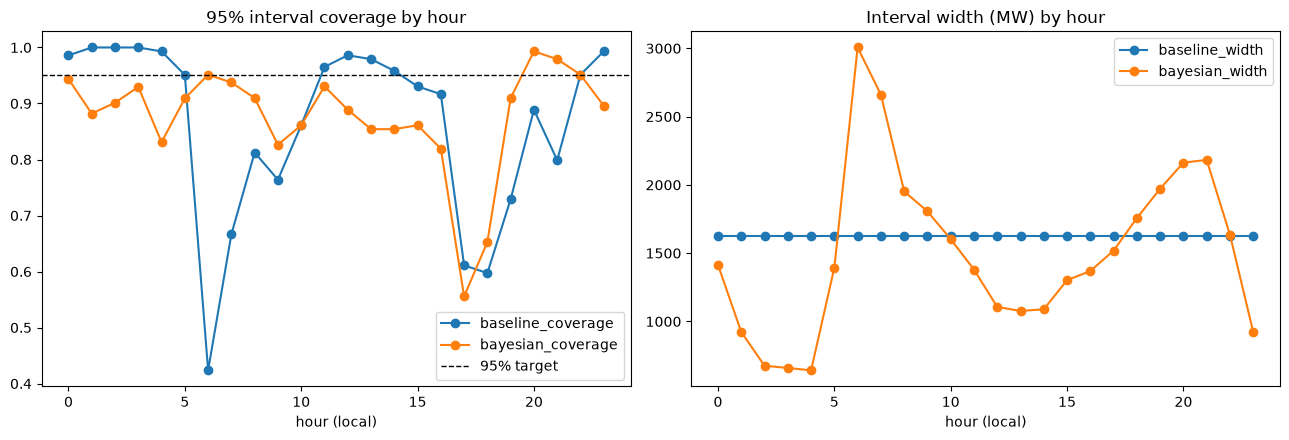

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

coverage_by_hour[["baseline_coverage", "bayesian_coverage"]].plot(ax=axes[0], marker="o")
axes[0].axhline(0.95, color="k", linestyle="--", linewidth=1, label="95% target")
axes[0].set_title("95% interval coverage by hour")
axes[0].set_xlabel("hour (local)")
axes[0].legend()

coverage_by_hour[["baseline_width", "bayesian_width"]].plot(ax=axes[1], marker="o")
axes[1].set_title("Interval width (MW) by hour")
axes[1].set_xlabel("hour (local)")

plt.tight_layout()
plt.show()

In [10]:
## 5b. Is the coverage undershoot a train/test seasonal shift, or a model flaw?
# Both baseline and Bayesian undershoot 95% on the real Oct-Dec test set above. To isolate
# "does the interval calibration work at all" from "does it survive a winter the model never
# trained on", re-split the *training* period only (Jan 8 - Oct 21, no December in either half)
# 80/20 chronologically and re-check coverage there. If coverage recovers to ~95% in-distribution,
# the undershoot above is a seasonal-shift artifact of this particular split, not a flaw in either
# model's uncertainty quantification.

train_only = df[df.index < split_date]
sub_split_date = train_only.index[int(len(train_only) * 0.8)]

sub_train_df, sub_test_df, sub_y_pred_train, sub_y_fore = _fit_mean_model(train_only, sub_split_date)
sub_y_resid = sub_train_df["ND"] - sub_y_pred_train
sub_train_hour = sub_train_df["hour"]
sub_test_hour = sub_test_df["hour"]

print(f"sub_train: {sub_train_df.index.min()} -> {sub_split_date}  (n={len(sub_train_df)})")
print(f"sub_test:  {sub_split_date} -> {sub_test_df.index.max()}  (n={len(sub_test_df)})")

sub_model = build_hierarchical_sigma_model(sub_y_resid, sub_train_hour, priors)
sub_trace = fit_hierarchical_sigma_model(sub_model, priors, random_seed=0)
sub_offsets = predict_interval(sub_model, sub_trace, sub_test_hour, priors, random_seed=0)

sub_bayesian_lower = sub_y_fore + sub_offsets["lower_offset"]
sub_bayesian_upper = sub_y_fore + sub_offsets["upper_offset"]
sub_actual = sub_test_df["ND"]

sub_baseline = forecast_with_interval(train_only, sub_split_date)

sub_bayes_covered = (sub_actual >= sub_bayesian_lower) & (sub_actual <= sub_bayesian_upper)
sub_baseline_covered = (sub_actual >= sub_baseline["Lower Forecast"]) & (sub_actual <= sub_baseline["Upper Forecast"])

print(f"\nIn-distribution overall coverage -- baseline: {sub_baseline_covered.mean():.3%}")
print(f"In-distribution overall coverage -- Bayesian hierarchical: {sub_bayes_covered.mean():.3%}")
print("(compare to the real Oct-Dec test set above: baseline 86.5%, Bayesian 87.7%)")

Initializing NUTS using jitter+adapt_diag...


sub_train: 2024-01-08 00:00:00+00:00 -> 2024-08-24 18:00:00+00:00  (n=11028)
sub_test:  2024-08-24 18:00:00+00:00 -> 2024-10-21 04:00:00+00:00  (n=2757)


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, tau, gamma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Sampling: [resid_obs]



In-distribution overall coverage -- baseline: 94.487%
In-distribution overall coverage -- Bayesian hierarchical: 95.103%
(compare to the real Oct-Dec test set above: baseline 86.5%, Bayesian 87.7%)


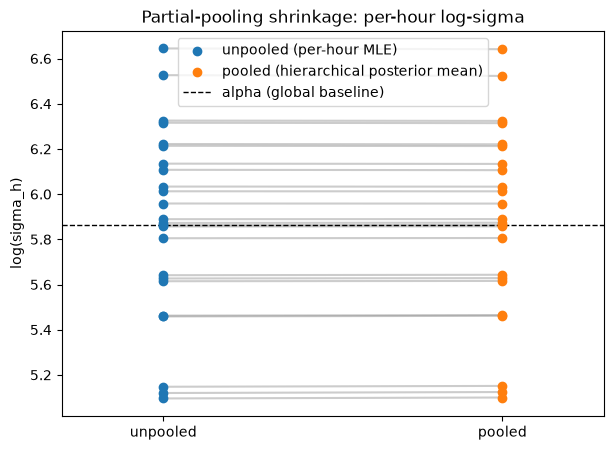

In [11]:
## 6. Shrinkage plot
# Unpooled per-hour std (each hour's own MLE, no borrowing across hours) vs the pooled
# hierarchical posterior mean, on the log scale the model actually works in. Confirms partial
# pooling is moving noisy estimates sensibly rather than collapsing to one extreme.

unpooled_std = y_resid.groupby(train_hour).std().reindex(range(priors.n_hour_buckets))
unpooled_log_sigma = np.log(unpooled_std)
pooled_log_sigma = np.log(trace.posterior["sigma_h"].mean(dim=("chain", "draw")).to_numpy())
alpha_mean = float(trace.posterior["alpha"].mean())

fig, ax = plt.subplots(figsize=(7, 5))
for h in range(priors.n_hour_buckets):
    ax.plot([0, 1], [unpooled_log_sigma.iloc[h], pooled_log_sigma[h]], color="gray", alpha=0.4)
ax.scatter(np.zeros(priors.n_hour_buckets), unpooled_log_sigma, label="unpooled (per-hour MLE)", zorder=3)
ax.scatter(np.ones(priors.n_hour_buckets), pooled_log_sigma, label="pooled (hierarchical posterior mean)", zorder=3)
ax.axhline(alpha_mean, color="k", linestyle="--", linewidth=1, label="alpha (global baseline)")
ax.set_xticks([0, 1])
ax.set_xticklabels(["unpooled", "pooled"])
ax.set_xlim(-0.3, 1.3)
ax.set_ylabel("log(sigma_h)")
ax.set_title("Partial-pooling shrinkage: per-hour log-sigma")
ax.legend()
plt.show()